# Ejercicio 4 - Segmentación de Imágenes Médicas

En esta seccion, desarrollaremos el EDA y ETL de la base de datos de **"Segmentación de Imágenes Médicas"** con el fin de comprender y analizar la problematica planteada.

A continuacion, instalaremos las librerias quer seran utilizadas a lo largo del ejercicio.

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import cv2
import tifffile
import seaborn as sns

In [4]:
df2 = pd.read_csv("HuBMAP-20-dataset_information.csv")
df2 = pd.DataFrame(df2)

df2

,image_file,width_pixels,height_pixels,anatomical_structures_segmention_file,glomerulus_segmentation_file,patient_number,race,ethnicity,sex,age,weight_kilograms,height_centimeters,bmi_kg/m^2,laterality,percent_cortex,percent_medulla
0,aa05346ff.tiff,47340,30720,aa05346ff-anatomical-structure.json,aa05346ff.json,67347,White,Not Hispanic or Latino,Female,58,59.0,160.0,23.0,Right,80,20
1,afa5e8098.tiff,43780,36800,afa5e8098-anatomical-structure.json,afa5e8098.json,67347,White,Not Hispanic or Latino,Female,58,59.0,160.0,23.0,Right,55,45
2,54f2eec69.tiff,22240,30440,54f2eec69-anatomical-structure.json,54f2eec69.json,67548,Black or African American,Not Hispanic or Latino,Male,58,79.9,190.5,22.0,Right,75,25
3,d488c759a.tiff,29020,46660,d488c759a-anatomical-structure.json,d488c759a.json,68138,White,Not Hispanic or Latino,Female,66,81.5,158.8,32.2,Left,100,0
4,1e2425f28.tiff,32220,26780,1e2425f28-anatomical-structure.json,1e2425f28.json,63921,White,Not Hispanic or Latino,Male,48,131.5,193.0,35.3,Right,65,35
5,e79de561c.tiff,27020,16180,e79de561c-anatomical-structure.json,e79de561c.json,67026,Black or African American,Not Hispanic or Latino,Male,53,73.0,166.0,26.5,Left,55,45
6,c68fe75ea.tiff,49780,26840,c68fe75ea-anatomical-structure.json,c68fe75ea.json,67112,White,Not Hispanic or Latino,Male,56,91.2,167.6,32.5,Left,80,20
7,095bf7a1f.tiff,39000,38160,095bf7a1f-anatomical-structure.json,095bf7a1f.json,68250,White,Not Hispanic or Latino,Female,44,71.7,160.0,28.0,Right,65,35
8,26dc41664.tiff,42360,38160,26dc41664-anatomical-structure.json,26dc41664.json,68304,White,Not Hispanic or Latino,Female,66,71.3,167.6,25.4,Left,55,45
9,57512b7f1.tiff,43160,33240,57512b7f1-anatomical-structure.json,57512b7f1.json,68555,White,Not Hispanic or Latino,Female,76,93.0,157.4,37.5,Left,80,20


In [5]:
print("\n Estructura del dataset:")
print(df2.shape)

print("\n Nombre de variables")
print(df2.columns)


 Estructura del dataset:
(20, 16)

 Nombre de variables
Index(['image_file', 'width_pixels', 'height_pixels',
       'anatomical_structures_segmention_file', 'glomerulus_segmentation_file',
       'patient_number', 'race', 'ethnicity', 'sex', 'age', 'weight_kilograms',
       'height_centimeters', 'bmi_kg/m^2', 'laterality', 'percent_cortex',
       'percent_medulla'],
      dtype='object')


In [6]:
df2.isnull().sum()

image_file                               0
width_pixels                             0
height_pixels                            0
anatomical_structures_segmention_file    0
glomerulus_segmentation_file             0
patient_number                           0
race                                     0
ethnicity                                0
sex                                      0
age                                      0
weight_kilograms                         1
height_centimeters                       1
bmi_kg/m^2                               1
laterality                               0
percent_cortex                           0
percent_medulla                          0
dtype: int64

Observamos que la base de datos contiene datos faltanes. Estos se encuentran en la muestra dek paciente '65631' el cual presenta NA en las variables 'height_centimeters', 'weight_kilograms', 'bmi_kg/m^2'. Al tener una base de datos con pocas muestras (20 en total), decidimos reemplazar los valores de NA por la mediana de cada variable en funcion del sexo, de esta forma mantenemos la armonia estadistica de los datos. 

In [7]:
df2['height_centimeters'] = df2.groupby('sex')['height_centimeters'].transform(
    lambda x: x.fillna(x.median())
)

df2['weight_kilograms'] = df2.groupby('sex')['weight_kilograms'].transform(
    lambda x: x.fillna(x.median())
)

df2['bmi_kg/m^2'] = df2.groupby('sex')['bmi_kg/m^2'].transform(
    lambda x: x.fillna(x.median())
)

df2.isnull().sum()

image_file                               0
width_pixels                             0
height_pixels                            0
anatomical_structures_segmention_file    0
glomerulus_segmentation_file             0
patient_number                           0
race                                     0
ethnicity                                0
sex                                      0
age                                      0
weight_kilograms                         0
height_centimeters                       0
bmi_kg/m^2                               0
laterality                               0
percent_cortex                           0
percent_medulla                          0
dtype: int64

Observamos que una vez realizado este cambio, contamos con la base de datos completa y con esto procederemos con el analisis demografico.

#### Analisis demografico 

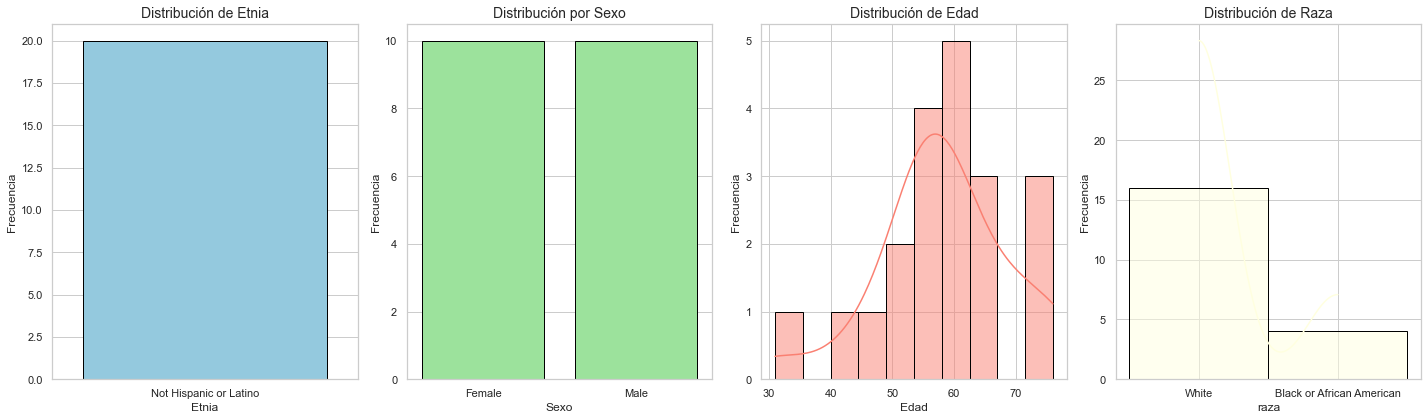

In [8]:
# Estilo general
sns.set(style="whitegrid", palette="pastel")
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

#  Gráfico de Etnia (categórica) 
sns.countplot(data=df2, x='ethnicity', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Distribución de Etnia', fontsize=14)
axes[0].set_xlabel('Etnia')
axes[0].set_ylabel('Frecuencia')

# 2. Gráfico de Sexo (categórica)
sns.countplot(data=df2, x='sex', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('Distribución por Sexo', fontsize=14)
axes[1].set_xlabel('Sexo')
axes[1].set_ylabel('Frecuencia')

# 3. Histograma de Edad (numérica)
sns.histplot(data=df2, x='age', bins=10, kde=True, ax=axes[2], color='salmon', edgecolor='black')
axes[2].set_title('Distribución de Edad', fontsize=14)
axes[2].set_xlabel('Edad')
axes[2].set_ylabel('Frecuencia')

# 3. Histograma de Edad (numérica)
sns.histplot(data=df2, x='race', bins=10, kde=True, ax=axes[3], color='lightyellow', edgecolor='black')
axes[3].set_title('Distribución de Raza', fontsize=14)
axes[3].set_xlabel('raza')
axes[3].set_ylabel('Frecuencia')

# Mostrar todo junto
plt.tight_layout()
plt.show()

Observamos...

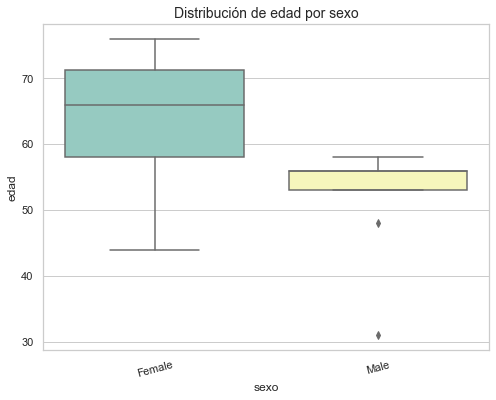

In [9]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df2, x='sex', y='age', palette='Set3')
plt.title("Distribución de edad por sexo", fontsize=14)
plt.ylabel("edad")
plt.xlabel("sexo")
plt.xticks(rotation=15)
plt.show()


observamos...

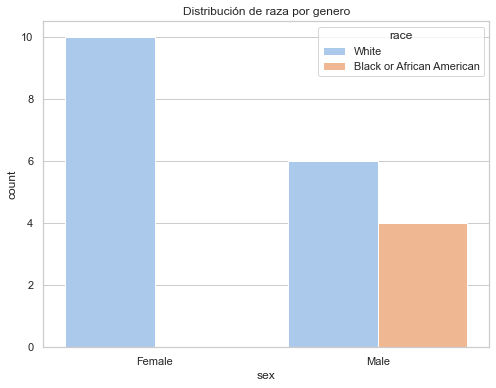

In [10]:
# Gráfico de barras agrupadas
plt.figure(figsize=(8,6))
sns.countplot(data=df2, x="sex", hue="race", palette="pastel")
plt.title("Distribución de raza por genero")
plt.show()

observamos...

#### Analisis de caracteristicas fisicas

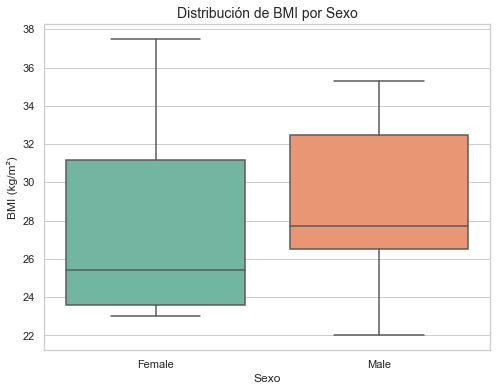

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df2, x='sex', y='bmi_kg/m^2', palette='Set2')
plt.title("Distribución de BMI por Sexo", fontsize=14)
plt.ylabel("BMI (kg/m²)")
plt.xlabel("Sexo")
plt.show()

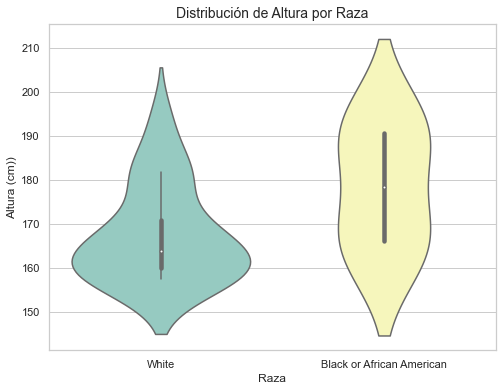

In [12]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=df2, x='race', y='height_centimeters', palette='Set3')
plt.title("Distribución de Altura por Raza", fontsize=14)
plt.ylabel("Altura (cm))")
plt.xlabel("Raza")
plt.show()

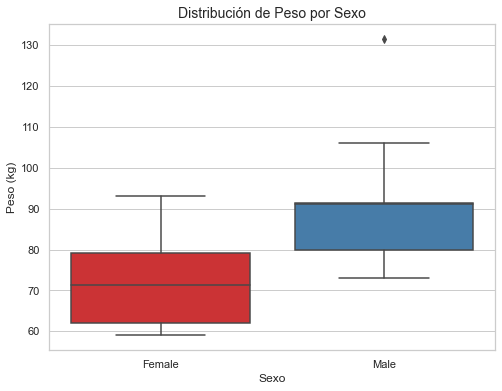

In [13]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df2, x='sex', y='weight_kilograms', palette='Set1')
plt.title("Distribución de Peso por Sexo", fontsize=14)
plt.ylabel("Peso (kg)")
plt.xlabel("Sexo")
plt.show()

#### 

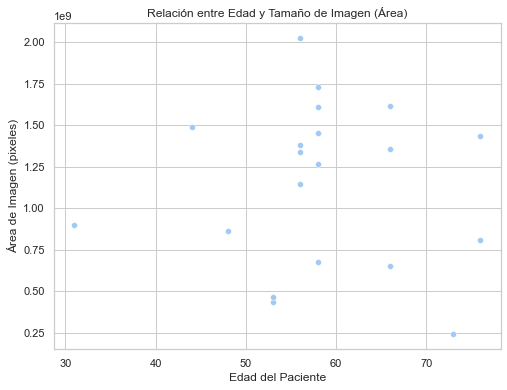

In [15]:
df2['image_area'] = df2['width_pixels'] * df2['height_pixels']

plt.figure(figsize=(8,6))
sns.scatterplot(data=df2, x='age', y='image_area')
plt.title('Relación entre Edad y Tamaño de Imagen (Área)')
plt.xlabel('Edad del Paciente')
plt.ylabel('Área de Imagen (pixeles)')
plt.show()

In [16]:
correlacion = df2['age'].corr(df2['image_area'])
print(f"Coeficiente de correlación: {correlacion:.2f}")

Coeficiente de correlación: -0.04


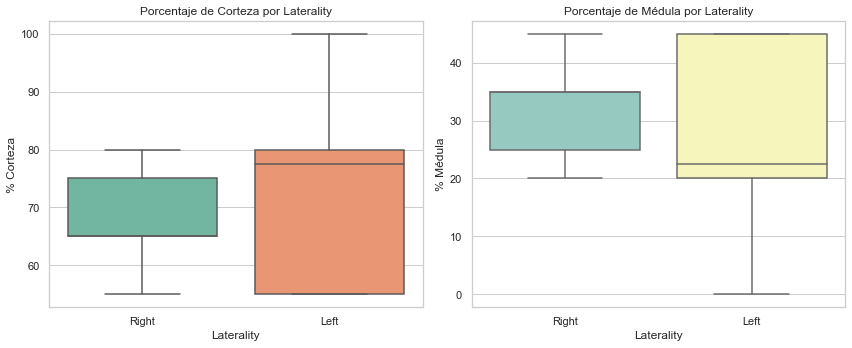

In [17]:
plt.figure(figsize=(12,5))

# Comparar percent_cortex
plt.subplot(1, 2, 1)
sns.boxplot(data=df2, x='laterality', y='percent_cortex', palette='Set2')
plt.title('Porcentaje de Corteza por Laterality')
plt.ylabel('% Corteza')
plt.xlabel('Laterality')

# Comparar percent_medulla
plt.subplot(1, 2, 2)
sns.boxplot(data=df2, x='laterality', y='percent_medulla', palette='Set3')
plt.title('Porcentaje de Médula por Laterality')
plt.ylabel('% Médula')
plt.xlabel('Laterality')

plt.tight_layout()
plt.show()

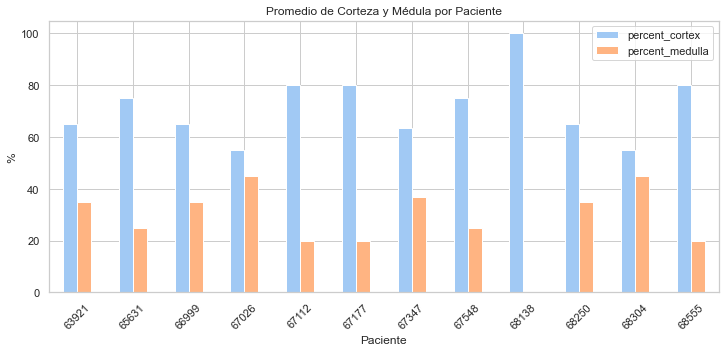

In [18]:
df2[['patient_number', 'percent_cortex', 'percent_medulla']].groupby('patient_number').mean().plot.bar(figsize=(12,5))
plt.title('Promedio de Corteza y Médula por Paciente')
plt.ylabel('%')
plt.xlabel('Paciente')
plt.xticks(rotation=45)
plt.show()